## First try exploration data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

data_path = Path("household_power_consumption.txt")
df = pd.read_csv(data_path, sep=";", na_values="?")


In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
def plot_groupby(df, group_by, target='Global_active_power'):
    """Group data by a time feature and plot the mean consumption."""
    
    # Parse datetime
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    df[group_by] = getattr(df['datetime'].dt, group_by)
    
    grouped = df.groupby(group_by)[target].mean()
    
    plt.figure(figsize=(10, 4))
    plt.plot(grouped.index, grouped.values, marker='o')
    plt.title(f'Mean {target} by {group_by}')
    plt.xlabel(group_by)
    plt.ylabel('kW')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



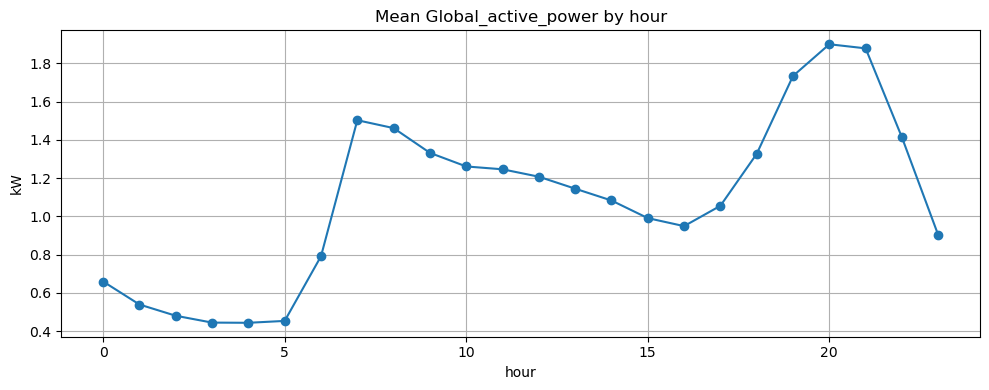

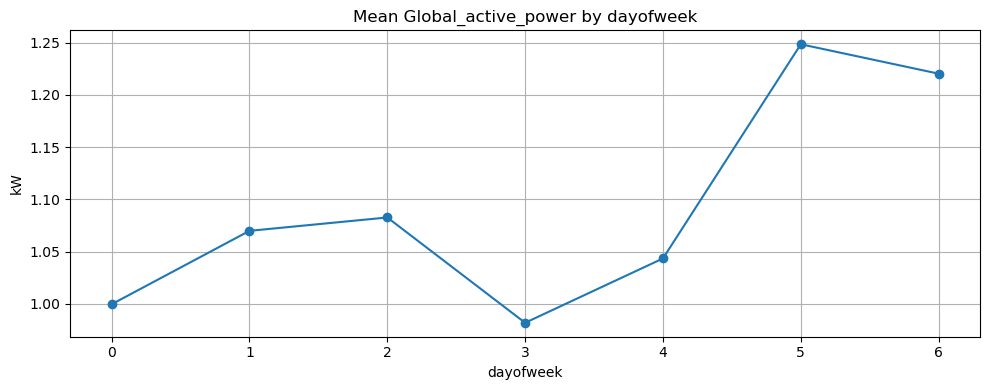

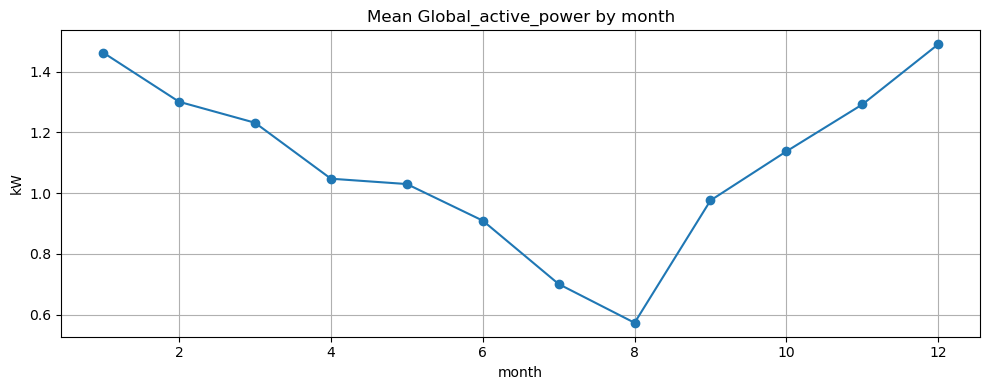

In [5]:

plot_groupby(df, 'hour')       # by hour
plot_groupby(df, 'dayofweek')  # by day of week (0=Mon, 6=Sun)
plot_groupby(df, 'month')      # by month

In [6]:
# make a copy of the dataframe for further processing
df_raw = df.copy()

In [7]:
df_work = df_raw.copy()

df_work["datetime"] = pd.to_datetime(
    df_work["Date"] + " " + df_work["Time"],
    dayfirst=True
)

df_work["Global_active_power"] = pd.to_numeric(
    df_work["Global_active_power"],
    errors="coerce"
)

df_work = df_work.set_index("datetime").sort_index()

hourly = df_work["Global_active_power"].resample("h").mean()
hourly = hourly.dropna()



In [8]:
hourly.tail()

datetime
2010-11-26 17:00:00    1.725900
2010-11-26 18:00:00    1.573467
2010-11-26 19:00:00    1.659333
2010-11-26 20:00:00    1.163700
2010-11-26 21:00:00    0.934667
Name: Global_active_power, dtype: float64

In [9]:
hourly.shape

(34168,)

In [10]:
# train test split
split_index = int(len(hourly) * 0.8)

train = hourly.iloc[:split_index]
test = hourly.iloc[split_index:]

In [11]:
y_train = train.values
y_test = test.values

In [12]:
# building fourier features for the hourly data for the linear regression model
# first building fourier features for the hourly data

from pyexpat import features


def hourly_fourier_features(data, K=3):
    """Generate Fourier features for hourly data."""
    
    hour = data.index.hour
    
    features = pd.DataFrame(index=data.index)
    
    
    for k in range(1, K + 1):
        features[f'sin_{k}'] = np.sin(2 * np.pi * k * hour / 24)
        features[f'cos_{k}'] = np.cos(2 * np.pi * k * hour / 24)
    
    return features

In [13]:
X_train = hourly_fourier_features(train, K=3)
X_test = hourly_fourier_features(test, K=3)

y_train = train.values
y_test = test.values

In [14]:
# Linear Regression for Global Active Power over time
# A linear model (OLS or Ridge)
# First ordinary least squares (OLS) regression

from sklearn.linear_model import LinearRegression

ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

y_pred_train = ols_model.predict(X_train)
y_pred_test = ols_model.predict(X_test)


In [15]:
# try OLS this time like in the homework

class OLSRegression:
    def __init__(self):
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        # convert pandas DataFrame/ Series to NumPy arrays if needed
        X = np.array(X)
        y = np.array(y)
        
        # Add bias column of ones
        X_b = np.column_stack([X, np.ones(X.shape[0])])

        # Solve least squares problem
        w_tilde = np.linalg.lstsq(X_b, y, rcond=None)[0]

        # Split weights and bias
        self.w = w_tilde[:-1]
        self.b = w_tilde[-1]

        return self

    def predict(self, X):
        X = np.asarray(X)
        return X @ self.w + self.b 
        
        

In [16]:
K = 3

X_train = hourly_fourier_features(train, K=K)
X_test = hourly_fourier_features(test, K=K)

y_train = train.values
y_test = test.values

model = OLSRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

Train RMSE: 0.825049187060662
Test RMSE: 0.6808557727123894
Train MAE: 0.6142487909342734
Test MAE: 0.5262337957436084


In [18]:
K_values = np.arange(1, 11, 1)
# K_values = [1, 3, 5, 10]

for K in K_values:
    X_train = hourly_fourier_features(train, K=K)
    X_test = hourly_fourier_features(test, K=K)

    model = OLSRegression()
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"K={K}, Test RMSE={test_rmse:.4f}")

K=1, Test RMSE=0.7269
K=2, Test RMSE=0.6821
K=3, Test RMSE=0.6809
K=4, Test RMSE=0.6737
K=5, Test RMSE=0.6722
K=6, Test RMSE=0.6717
K=7, Test RMSE=0.6708
K=8, Test RMSE=0.6705
K=9, Test RMSE=0.6704
K=10, Test RMSE=0.6700


In [19]:
# building OSL with hourly + weekly fourier features

def weekly_fourier_features(data, K=3):
    """Generate Fourier features for weekly data."""
    
    weekly = data.index.dayofweek * 24 + data.index.hour  # Convert to hours since start of week
    period = 24 * 7  # Total hours in a week
    
    features = pd.DataFrame(index=data.index)
    
    
    for k in range(1, K + 1):
        features[f"week_sin_{k}"] = np.sin((2 * np.pi * k * weekly) / period)
        features[f"week_cos_{k}"] = np.cos((2 * np.pi * k * weekly) / period)
    
    return features


In [20]:
K = 3

X_train_hour = hourly_fourier_features(train, K=K)
X_train_week = weekly_fourier_features(train, K=K)

X_test_hour = hourly_fourier_features(test, K=K)
X_test_week = weekly_fourier_features(test, K=K)

X_train = pd.concat([X_train_hour, X_train_week], axis=1)
X_test = pd.concat([X_test_hour, X_test_week], axis=1)

In [21]:

# train OLS model with hourly + weekly features

model = OLSRegression()
model.fit(X_train, y_train)

# predicting on train and test data
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# evaluating the model
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train MAE:", train_mae)
print("Test MAE:", test_mae)



Train RMSE: 0.8177402153031913
Test RMSE: 0.6845910141971976
Train MAE: 0.6127985534401611
Test MAE: 0.5327688160438223


## Results comparing the model with additional features

Adding weekly Fourier features slightly reduced the training error, but did not improve test performance. This suggests that the weekly cycle either is weak in this dataset split or that the additional features lead to mild overfitting.

In [22]:
K_values = np.arange(1, 11, 1)
# K_values = [1, 3, 5, 10]

for K in K_values:
    X_train = weekly_fourier_features(train, K=K)
    X_test = weekly_fourier_features(test, K=K)

    model = OLSRegression()
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"K={K}, Test RMSE={test_rmse:.4f}")

K=1, Test RMSE=0.7506
K=2, Test RMSE=0.7522
K=3, Test RMSE=0.7531
K=4, Test RMSE=0.7529
K=5, Test RMSE=0.7540
K=6, Test RMSE=0.7518
K=7, Test RMSE=0.7287
K=8, Test RMSE=0.7279
K=9, Test RMSE=0.7278
K=10, Test RMSE=0.7279


Now try out Ridge Regression for the data before adding more fourier features and compare the results

In [23]:
# ridge regression with hourly + weekly fourier features

class RidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        # convert pandas DataFrame/ Series to NumPy arrays if needed
        X = np.array(X)
        y = np.array(y)
        
        # Add bias column of ones
        X_b = np.column_stack([X, np.ones(X.shape[0])])

        # Solve ridge regression problem
        n_features = X_b.shape[1]
        
        regularization = np.eye(n_features)
        regularization[-1, -1] = 0  # Do not regularize the bias term
        
        A = X_b.T @ X_b + self.alpha * regularization
        b = X_b.T @ y
        
        w_tilde = np.linalg.solve(A, b)

        # Split weights and bias
        self.w = w_tilde[:-1]
        self.b = w_tilde[-1]

        return self

    def predict(self, X):
        X = np.asarray(X)
        return X @ self.w + self.b

In [24]:
ridge = RidgeRegression(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

In [25]:
alpha_values = [0.01, 0.1, 1, 10, 100]

for alpha in alpha_values:
    X_train = pd.concat([hourly_fourier_features(train, K=3), weekly_fourier_features(train, K=3)], axis=1)
    X_test = pd.concat([hourly_fourier_features(test, K=3), weekly_fourier_features(test, K=3)], axis=1)
    
    model = RidgeRegression(alpha=alpha)
    model.fit(X_train, y_train)
    
    y_pred_test = model.predict(X_test)
    
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"Alpha={alpha}, Test RMSE={test_rmse:.4f}")

Alpha=0.01, Test RMSE=0.6846
Alpha=0.1, Test RMSE=0.6846
Alpha=1, Test RMSE=0.6846
Alpha=10, Test RMSE=0.6845
Alpha=100, Test RMSE=0.6840


In [26]:
# K_values = np.arange(1, 11, 1)
K_values =[1, 3, 5, 10]
alpha_values = [0.01, 0.1, 1, 10, 100]

for K in K_values:
    print(f"\nK={K}")
    
    X_train = pd.concat([
        hourly_fourier_features(train, K=K),
        weekly_fourier_features(train, K=K)
    ], axis=1)

    X_test = pd.concat([
        hourly_fourier_features(test, K=K),
        weekly_fourier_features(test, K=K)
    ], axis=1)
    
    for alpha in alpha_values:
        model = RidgeRegression(alpha=alpha)
        model.fit(X_train, y_train)
        
        y_pred_test = model.predict(X_test)
        
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        print(f"Alpha={alpha}, Test RMSE={test_rmse:.4f}")


K=1
Alpha=0.01, Test RMSE=0.7279
Alpha=0.1, Test RMSE=0.7279
Alpha=1, Test RMSE=0.7279
Alpha=10, Test RMSE=0.7279
Alpha=100, Test RMSE=0.7277

K=3


Alpha=0.01, Test RMSE=0.6846
Alpha=0.1, Test RMSE=0.6846
Alpha=1, Test RMSE=0.6846
Alpha=10, Test RMSE=0.6845
Alpha=100, Test RMSE=0.6840

K=5
Alpha=0.01, Test RMSE=0.6767
Alpha=0.1, Test RMSE=0.6767
Alpha=1, Test RMSE=0.6767
Alpha=10, Test RMSE=0.6766
Alpha=100, Test RMSE=0.6761

K=10
Alpha=0.01, Test RMSE=0.6710
Alpha=0.1, Test RMSE=0.6710
Alpha=1, Test RMSE=0.6710
Alpha=10, Test RMSE=0.6709
Alpha=100, Test RMSE=0.6704


In [27]:
K_values = [1, 3, 5, 10]

for K in K_values:
    X_train = pd.concat([
        hourly_fourier_features(train, K=K),
        weekly_fourier_features(train, K=K)
    ], axis=1)

    X_test = pd.concat([
        hourly_fourier_features(test, K=K),
        weekly_fourier_features(test, K=K)
    ], axis=1)

    model = OLSRegression()
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"K={K}, Test RMSE={test_rmse:.4f}")

K=1, Test RMSE=0.7279
K=3, Test RMSE=0.6846
K=5, Test RMSE=0.6767
K=10, Test RMSE=0.6710


In [28]:
# building OSL with hourly + weekly + yearly fourier features

def yearly_fourier_features(data, K=3):
    """Generate Fourier features for yearly data."""
    
    yearly = (data.index.dayofyear - 1) * 24 + data.index.hour  # Day of the year
    period = 365 * 24  # Total hours in a year
    
    features = pd.DataFrame(index=data.index)
    
    
    for k in range(1, K + 1):
        features[f"year_sin_{k}"] = np.sin((2 * np.pi * k * yearly) / period)
        features[f"year_cos_{k}"] = np.cos((2 * np.pi * k * yearly) / period)
    
    return features

In [29]:
K_values = np.arange(1, 11, 1)

for K in K_values:
    X_train = pd.concat([
        hourly_fourier_features(train, K=K),
        weekly_fourier_features(train, K=K),
        yearly_fourier_features(train, K=K)
    ], axis=1)

    X_test = pd.concat([
        hourly_fourier_features(test, K=K),
        weekly_fourier_features(test, K=K),
        yearly_fourier_features(test, K=K)
    ], axis=1)

    model = OLSRegression()
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"K={K}, Test RMSE={test_rmse:.4f}")

K=1, Test RMSE=0.7028
K=2, Test RMSE=0.6538
K=3, Test RMSE=0.6494
K=4, Test RMSE=0.6391
K=5, Test RMSE=0.6380
K=6, Test RMSE=0.6362
K=7, Test RMSE=0.6327
K=8, Test RMSE=0.6321
K=9, Test RMSE=0.6304
K=10, Test RMSE=0.6312


In [30]:
K_values = [1, 3, 5, 10]
alpha_values = [0.01, 0.1, 1, 10, 100]

for K in K_values:
    print(f"\nK={K}")

    X_train = pd.concat([
        hourly_fourier_features(train, K=K),
        weekly_fourier_features(train, K=K),
        yearly_fourier_features(train, K=K)
    ], axis=1)

    X_test = pd.concat([
        hourly_fourier_features(test, K=K),
        weekly_fourier_features(test, K=K),
        yearly_fourier_features(test, K=K)
    ], axis=1)

    for alpha in alpha_values:
        model = RidgeRegression(alpha=alpha)
        model.fit(X_train, y_train)

        y_pred_test = model.predict(X_test)

        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        print(f"Alpha={alpha}, Test RMSE={test_rmse:.4f}")


K=1
Alpha=0.01, Test RMSE=0.7028
Alpha=0.1, Test RMSE=0.7028
Alpha=1, Test RMSE=0.7028
Alpha=10, Test RMSE=0.7028
Alpha=100, Test RMSE=0.7026

K=3
Alpha=0.01, Test RMSE=0.6494
Alpha=0.1, Test RMSE=0.6494
Alpha=1, Test RMSE=0.6494
Alpha=10, Test RMSE=0.6493
Alpha=100, Test RMSE=0.6487

K=5
Alpha=0.01, Test RMSE=0.6380
Alpha=0.1, Test RMSE=0.6380
Alpha=1, Test RMSE=0.6380
Alpha=10, Test RMSE=0.6380
Alpha=100, Test RMSE=0.6373

K=10
Alpha=0.01, Test RMSE=0.6312
Alpha=0.1, Test RMSE=0.6312
Alpha=1, Test RMSE=0.6312
Alpha=10, Test RMSE=0.6311
Alpha=100, Test RMSE=0.6304


In [31]:
# summerize all the results in a table for comparison

results = []

In [32]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)

    return train_rmse, test_rmse, train_mae, test_mae

In [33]:
def make_features(data, K, feature_set):
    feature_list = []

    if "hour" in feature_set:
        feature_list.append(hourly_fourier_features(data, K=K))

    if "week" in feature_set:
        feature_list.append(weekly_fourier_features(data, K=K))

    if "year" in feature_set:
        feature_list.append(yearly_fourier_features(data, K=K))

    return pd.concat(feature_list, axis=1)

In [34]:
results = []

K_values = np.arange(1, 11)

feature_sets = {
    "Hour only": ["hour"],
    "Hour + week": ["hour", "week"],
    "Year only": ["year"],
    "Hour + week + year": ["hour", "week", "year"]
}

for feature_name, feature_set in feature_sets.items():
    for K in K_values:
        X_train = make_features(train, K, feature_set)
        X_test = make_features(test, K, feature_set)

        model = OLSRegression()
        model.fit(X_train, y_train)

        train_rmse, test_rmse, train_mae, test_mae = evaluate_model(
            model, X_train, y_train, X_test, y_test
        )

        results.append({
            "Model": "OLS",
            "Features": feature_name,
            "K": K,
            "Alpha": None,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse,
            "Train MAE": train_mae,
            "Test MAE": test_mae
        })

In [35]:
alpha_values = [0.01, 0.1, 1, 10, 100]

for feature_name, feature_set in feature_sets.items():
    for K in K_values:
        X_train = make_features(train, K, feature_set)
        X_test = make_features(test, K, feature_set)

        for alpha in alpha_values:
            model = RidgeRegression(alpha=alpha)
            model.fit(X_train, y_train)

            train_rmse, test_rmse, train_mae, test_mae = evaluate_model(
                model, X_train, y_train, X_test, y_test
            )

            results.append({
                "Model": "Ridge",
                "Features": feature_name,
                "K": K,
                "Alpha": alpha,
                "Train RMSE": train_rmse,
                "Test RMSE": test_rmse,
                "Train MAE": train_mae,
                "Test MAE": test_mae
            })

In [36]:
results_df = pd.DataFrame(results)
results_df

,Model,Features,K,Alpha,Train RMSE,Test RMSE,Train MAE,Test MAE
0,OLS,Hour only,1,NaN,0.899558,0.726939,0.713769,0.595157
1,OLS,Hour only,2,NaN,0.827756,0.682111,0.616096,0.525579
2,OLS,Hour only,3,NaN,0.825049,0.680856,0.614249,0.526234
3,OLS,Hour only,4,NaN,0.815673,0.673663,0.604064,0.513210
4,OLS,Hour only,5,NaN,0.814182,0.672198,0.602256,0.511710
...,...,...,...,...,...,...,...,...
235,Ridge,Hour + week + year,10,0.01,0.737031,0.631161,0.547873,0.477200
236,Ridge,Hour + week + year,10,0.10,0.737031,0.631160,0.547874,0.477200
237,Ridge,Hour + week + year,10,1.00,0.737031,0.631154,0.547874,0.477196
238,Ridge,Hour + week + year,10,10.00,0.737031,0.631086,0.547884,0.477158


In [37]:
best_results = (
    results_df
    .sort_values("Test RMSE")
    .groupby(["Model", "Features"], as_index=False)
    .first()
)

best_results

,Model,Features,K,Alpha,Train RMSE,Test RMSE,Train MAE,Test MAE
0,OLS,Hour + week,10,NaN,0.793506,0.670970,0.583620,0.505898
1,OLS,Hour + week + year,9,NaN,0.739414,0.630443,0.549975,0.476733
2,OLS,Hour only,10,NaN,0.812330,0.669986,0.600165,0.509176
3,OLS,Year only,9,NaN,0.883923,0.713257,0.696973,0.574787
4,Ridge,Hour + week,10,100.0,0.793513,0.670366,0.584187,0.506039
5,Ridge,Hour + week + year,9,100.0,0.739424,0.629726,0.550070,0.476311
6,Ridge,Hour only,10,100.0,0.812337,0.669484,0.600787,0.509463
7,Ridge,Year only,9,100.0,0.883925,0.713181,0.697168,0.575040


In [38]:
best_results.sort_values("Test RMSE")

,Model,Features,K,Alpha,Train RMSE,Test RMSE,Train MAE,Test MAE
5,Ridge,Hour + week + year,9,100.0,0.739424,0.629726,0.550070,0.476311
1,OLS,Hour + week + year,9,NaN,0.739414,0.630443,0.549975,0.476733
6,Ridge,Hour only,10,100.0,0.812337,0.669484,0.600787,0.509463
2,OLS,Hour only,10,NaN,0.812330,0.669986,0.600165,0.509176
4,Ridge,Hour + week,10,100.0,0.793513,0.670366,0.584187,0.506039
0,OLS,Hour + week,10,NaN,0.793506,0.670970,0.583620,0.505898
7,Ridge,Year only,9,100.0,0.883925,0.713181,0.697168,0.575040
3,OLS,Year only,9,NaN,0.883923,0.713257,0.696973,0.574787


# Visulizations

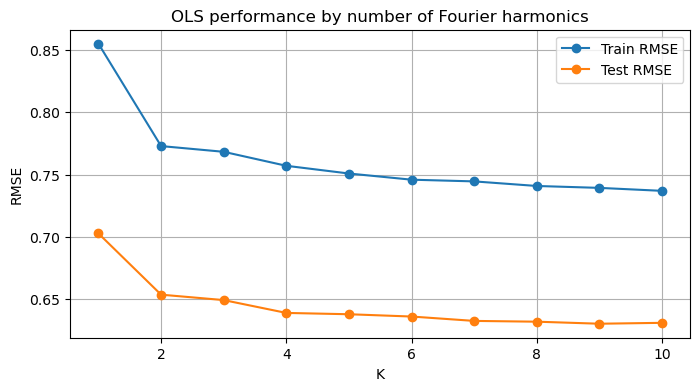

In [39]:
# RMSE vs. K for the best model (OLS with Hour + week + year features)

plot_df = results_df[
    (results_df["Model"] == "OLS") &
    (results_df["Features"] == "Hour + week + year")
]

plt.figure(figsize=(8, 4))
plt.plot(plot_df["K"], plot_df["Train RMSE"], marker="o", label="Train RMSE")
plt.plot(plot_df["K"], plot_df["Test RMSE"], marker="o", label="Test RMSE")

plt.title("OLS performance by number of Fourier harmonics")
plt.xlabel("K")
plt.ylabel("RMSE")
plt.grid(True)
plt.legend()
plt.show()

In [40]:
# actual vs. predicted for the best model (OLS with Hour + week + year features, K=9)

K = 9

X_train = pd.concat([
    hourly_fourier_features(train, K=K),
    weekly_fourier_features(train, K=K),
    yearly_fourier_features(train, K=K)
], axis=1)

X_test = pd.concat([
    hourly_fourier_features(test, K=K),
    weekly_fourier_features(test, K=K),
    yearly_fourier_features(test, K=K)
], axis=1)

model = OLSRegression()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)

prediction_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_test
}, index=test.index)

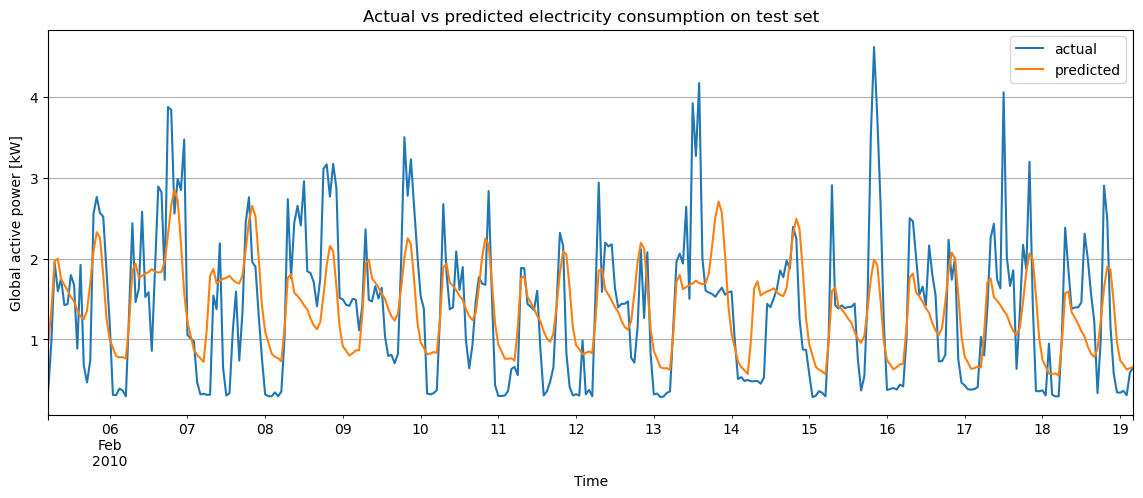

In [41]:
# plot only the first two weeks of the test set

prediction_df.iloc[:24*14].plot(figsize=(14, 5))

plt.title("Actual vs predicted electricity consumption on test set")
plt.xlabel("Time")
plt.ylabel("Global active power [kW]")
plt.grid(True)
plt.show()

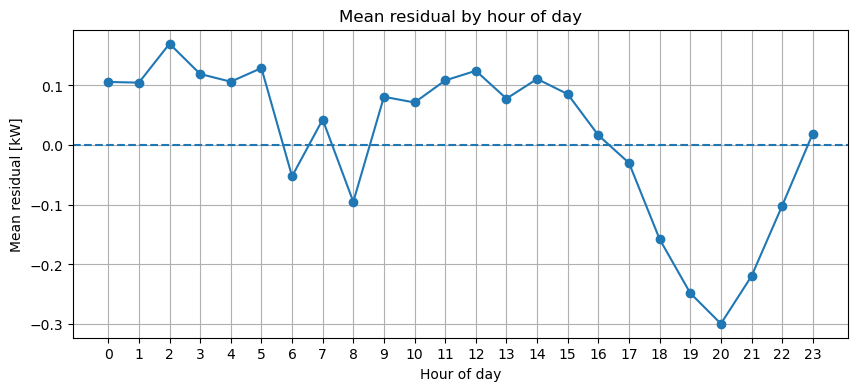

In [42]:
# residuals by hour

prediction_df["residual"] = prediction_df["actual"] - prediction_df["predicted"]
prediction_df["hour"] = prediction_df.index.hour

residual_by_hour = prediction_df.groupby("hour")["residual"].mean()

plt.figure(figsize=(10, 4))
plt.plot(residual_by_hour.index, residual_by_hour.values, marker="o")
plt.axhline(0, linestyle="--")

plt.title("Mean residual by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Mean residual [kW]")
plt.xticks(range(24))
plt.grid(True)
plt.show()